In [1]:
import numpy as np
import networkx as nx
from typing import List
import sys
from test_multicommodity import test_main

In [2]:
def read_coordinate(path="../data/input/coord.dat"):
    with open(path) as f:
        return [tuple(map(lambda x: round(float(x) * 20), line.split()[:2])) for line in f if line.strip()]


def create_raw_forcing(path="../data/input/rhs.dat"):
    def rhs(forcing, rho: float=0.0):
        g_forcing = forcing - rho * (forcing - np.mean(forcing))
        num_node = len(forcing)
        forcing_mat = np.zeros((num_node, num_node))
        for n in range(num_node):
            sum_g = np.sum(g_forcing) - g_forcing[n]
            sum_g -= g_forcing[n]
            coeff_r = g_forcing / sum_g
            forcing_mat[:, n] = -coeff_r * g_forcing[n]
            forcing_mat[n, n] = g_forcing[n]
        return forcing_mat
    
    with open(path) as forcing_f:
        lines = forcing_f.readlines()
        ncomm = len(lines)
        temp_forcing = np.zeros((ncomm, 3))
        for i, line in enumerate(lines):
            temp_forcing[i, :] = np.array([int(float(element)) for element in line.strip().split(" ")])
        return temp_forcing[:, :-1]

def rhs_construction(forcing, rho=0):
    g_forcing = forcing - rho * (forcing - np.mean(forcing))
    num_node = len(forcing)
    raw_forcing = np.zeros((num_node, num_node))
    for n in range(num_node):
        sum_g = np.sum(g_forcing)
        sum_g -= g_forcing[n]
        coeff_r = g_forcing / sum_g
        raw_forcing[:, n] = -coeff_r * g_forcing[n]
        raw_forcing[n, n] = g_forcing[n]
    return raw_forcing


coordinates = read_coordinate()
forcing = create_raw_forcing()
raw_forcing_mat = rhs_construction(forcing[:, 1])

In [3]:
def idx(coord):
    return coord[0] * 20 + coord[1]

In [4]:
mesh = nx.grid_2d_graph(20, 20)

In [5]:
forcing = np.zeros((400, 400))
num_node = len(coordinates)
for i in range(num_node):
    for j in range(num_node):
        forcing[idx(coordinates[i])][idx(coordinates[j])] = raw_forcing_mat[i][j]

In [6]:
edge_lists = np.array([list((idx(e[0]), idx(e[1]))) for e in mesh.edges()])
weights = np.ones_like(edge_lists[:,0])
forcing_ = [forcing[:, i] / 10000 for i in range(forcing.shape[1])]

Rhs149 is not balanced 9.2E-01
Rhs169 is not balanced 9.2E-01
Rhs170 is not balanced 9.2E-01
Rhs171 is not balanced 9.3E-01
Rhs188 is not balanced 9.2E-01
Rhs189 is not balanced 9.2E-01
Rhs190 is not balanced 9.2E-01
Rhs191 is not balanced 9.2E-01
Rhs192 is not balanced 9.2E-01
Rhs207 is not balanced 9.2E-01
Rhs208 is not balanced 9.2E-01
Rhs209 is not balanced 9.2E-01
Rhs210 is not balanced 9.2E-01
Rhs211 is not balanced 9.2E-01
Rhs212 is not balanced 9.2E-01
Rhs213 is not balanced 9.2E-01
Rhs228 is not balanced 9.2E-01
Rhs229 is not balanced 9.2E-01
Rhs230 is not balanced 9.2E-01
Rhs231 is not balanced 9.2E-01
Rhs232 is not balanced 9.2E-01
Rhs247 is not balanced 9.2E-01
Rhs248 is not balanced 9.2E-01
Rhs249 is not balanced 9.2E-01
Rhs250 is not balanced 9.2E-01
Rhs251 is not balanced 9.2E-01
Error in inputs at time t= 0.0


/home/oreki/admk_thesis/tests/../src/admk/admk_graph.py:136: RuntimeWarning: invalid value encountered in scalar divide
  balance = np.sum(self.rhs[begin:end])/np.linalg.norm(self.rhs[begin:end])


ierr=0 avg_it=0000 max(res)=3.4e-09 max(pres)=3.0e-06
   2.09e+00<=UPDATE<=4.21e+04, deltat=9.50e-05
ierr=0 avg_it=0000 max(res)=1.8e-09 max(pres)=1.8e-06
it=1 var=2.50e+03
   1.27e+00<=UPDATE<=2.08e+04, deltat=1.11e-03
ierr=0 avg_it=0000 max(res)=7.1e-09 max(pres)=4.9e-06
it=2 var=6.13e+02
   1.05e+00<=UPDATE<=6.05e+03, deltat=1.28e-02
ierr=0 avg_it=0000 max(res)=1.3e-09 max(pres)=9.1e-07
it=3 var=5.52e+01
   1.13e+00<=UPDATE<=1.77e+03, deltat=1.00e-01
ierr=0 avg_it=0000 max(res)=8.1e-09 max(pres)=6.0e-06
it=4 var=6.18e+00
   -2.55e-01<=UPDATE<=4.57e+02, deltat=1.00e-01
ierr=0 avg_it=0000 max(res)=1.0e-08 max(pres)=3.5e-06
it=5 var=1.37e+00
   -6.66e-01<=UPDATE<=3.15e+02, deltat=1.00e-01
ierr=0 avg_it=0000 max(res)=1.1e-09 max(pres)=6.2e-07
it=6 var=8.62e-01
   -1.02e+00<=UPDATE<=2.31e+02, deltat=1.00e-01
ierr=0 avg_it=0000 max(res)=8.4e-09 max(pres)=1.3e-06
it=7 var=5.95e-01
   -1.54e+00<=UPDATE<=1.75e+02, deltat=1.00e-01
ierr=0 avg_it=0000 max(res)=7.1e-09 max(pres)=2.8e-06
it=8 var

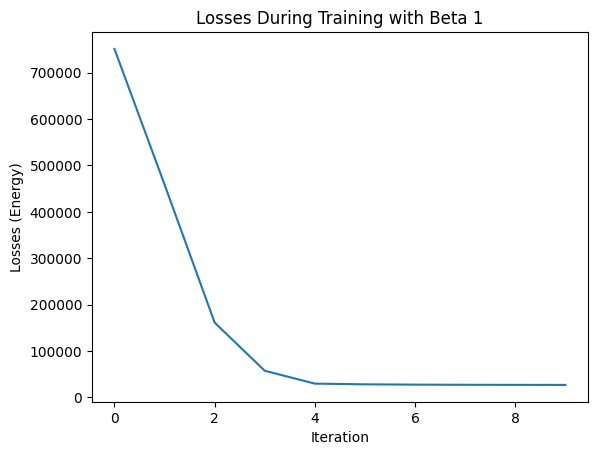

In [7]:
potentials, conductivity_admk = test_main(edge_lists, weights, len(forcing_), forcing_, beta=1, max_iter=10)

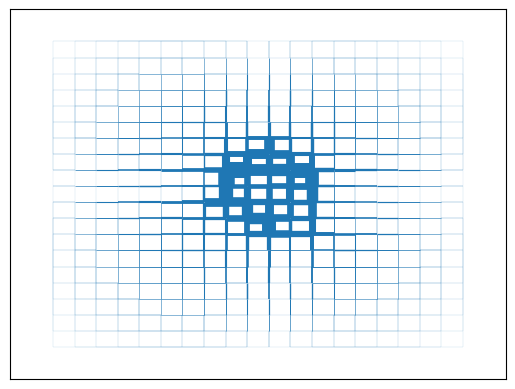

In [8]:
nx.draw_networkx_edges(mesh, {n: n for n in mesh.nodes()}, width=conductivity_admk / np.linalg.norm(conductivity_admk) * 50,  edge_color='C0', style='solid')